# TSIA202a - First Practice Session
The goal of this first practical work is to experiment the estimation of second order moments for
random processes, and to simply compare them with their theoretical version.

Let consider the following real processes:
-  White Noise (denoted $\text{WN}$): $Z_t$ with variance $\sigma^2$ (use `np.random.normal`)
- $X_t=a+bZ_t+Z_{t-1}$ where $Z_t \sim \text{WN}\left(0,\sigma^2\right)$
- $X_t = \sum_{k=0}^{K}2^{-k}Z_{t-k} + a$ (with $K$ "big enough" $K \to \infty$ ?)
- Harmonic Process: $X_t=A_0\cos(\lambda_0t+\Phi_0)+Z_t$ where $\lambda_0 \in [0,\pi],$ $\Phi_0 \sim {U}([0,2\pi])$ (*e.g.* `np.random.uniform`)

For each of them:
1. Compute the theoretical mean and autocovariance of the previous mentioned real processes using the formulas $\mathbb{E}(X_n)$ and $\mathrm{Cov}(X_{n},X_{n+h})$.

2. Compute the empirical mean and empirical autocovariance function using course's formulas in `python`.

3. Plot the theoretical operator and empirical estimators for various sampling many times and comment.
4. For a given number $ T \in \{10, 100, 500, 1000\}$ of samples $X_1, \dots, X_T$:
  - For a given draw, compute the mean squared error (MSE) $\frac{1}{T}\sum_t (\gamma_{t} - \hat{\gamma_{t}})^2$ between the theoretical and the empirical autocovariance function denoted $\gamma$ and $\hat{\gamma}$ respectively.
  - Repeat the previous step $100$ times and saves all the results.
  - Compute the boxplot of the MSE for each $T$ and comment.


1. **[ANSWER]** For the mentionned random processes :

- $Z_t \Rightarrow$ $\mathbb{E}(Z_t) = 0$ and $\gamma(h) = Cov(X_{t+h},X_t) = \left\{
    \begin{array}{ll}
        1 & \mbox{if } h=0 \\
        0 & \mbox{otherwise.}
    \end{array}
\right.$

- $X_t=a+bZ_t+Z_{t-1}$ $\Rightarrow$ $\mathbb{E}(X_t) = a$ and $\gamma(h) = Cov(X_{t+h},X_t)=\left\{
    \begin{array}{ll}
        (b^2+1)\sigma^2 & \mbox{if } h=0 \\
        b\sigma^2 & \mbox{if } h\in\{-1,1\} \\
        0 & \mbox{otherwise.}
    \end{array}
\right.$
- $X_t = \sum_{k=0}^{K}2^{-k}Z_{t-k} + a$ $\Rightarrow$ $\mathbb{E}(X_t) = a$ and $\gamma(h) = Cov(X_{t+h},X_t)=\left\{
    \begin{array}{ll}
        \frac{4^{-\frac{3h}{2}+1}}{3}(1-4^{-(K+1)})\sigma^2 & \mbox{if } 0\leq h \leq K \\
        \frac{4^{-\frac{h}{2}+1}}{3}(1-4^{-(K+h+1)})\sigma^2 & \mbox{if } -K \leq h \leq 0 \\
        0 & \mbox{otherwise.}\\
    \end{array}
\right.$
- $X_t=A_0\cos(\lambda_0t+\Phi_0)+Z_t$ $\Rightarrow$ $\mathbb{E}(X_t) _= A_0\mathbb{E}(cos(\lambda_0t+\Phi_0))$
$\mathbb{E}(cos(\lambda_0t+\Phi_0)) = \int_{0}^{2\pi} cos(\lambda_0t+\Phi_0) \frac{1}{2\pi}d\Phi_0=\frac{1}{2\pi}[sin(\lambda_0t+\Phi_0)]_{0}^{2\pi}=0$

    So : $\mathbb{E}(X_t)=0$

    If $h\neq 0$
    $\gamma(h) = Cov(X_{t+h},X_t)=A_0^2Cov[cos(λ_0(t+h)+\Phi_0),cos(λ_0t+\Phi_0)]$
    
    If $h=0$ we get : $\gamma(h) = A_0^2Cov[cos(λ_0(t+h)+\Phi_0),cos(λ_0t+\Phi_0)] + \sigma^2$ (here $Cov(Z_{t+h}, Z_t)=\sigma^2$ because $h=0$)

    We have : $Cov[cos(λ_0(t+h)+\Phi_0),cos(λ_0t+\Phi_0)]=\int_0^{2\pi}cos(λ_0(t+h)+\Phi_0)cos(λ_0t+\Phi_0)d\Phi_0 = \frac{1}{2}cos(\lambda_0h)$

  **C/C:** $\mathbb{E}(X_t)=0$ and $\gamma(h) = Cov(X_{t+h},X_t) = \left\{
    \begin{array}{ll}
        \frac{A_0^2}{2}+\sigma^2 & \mbox{if } h=0 \\
        \frac{A_0^2}{2}cos(\lambda_0h) & \mbox{otherwise.}
    \end{array}
\right.$

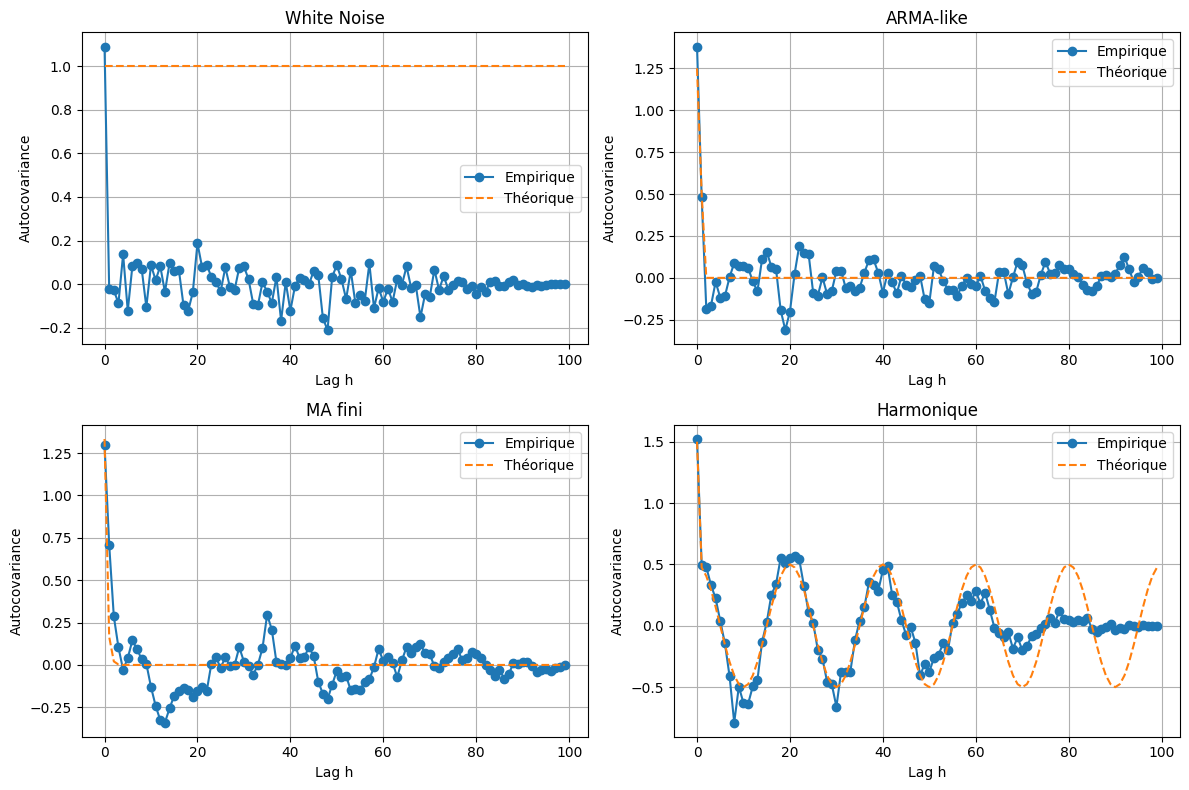

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Paramètres
# ---------------------------
T = 100
sigma = 1.0
a = 0.0
b = 0.5
K = 50
A0 = 1.0
lambda0 = np.pi / 10


# ---------------------------
# Utilities
# ---------------------------
def empirical_mean(X):
    """Return sample mean."""
    # TODO: implement empirical mean
    # hint: use numpy
    return (1/T)*sum(X)


def empirical_autocov(X, h_max=None):
    """
    Empirical autocovariance for lags 0..h_max.
    ALSO: center with empirical_mean(X).
    """
    T = len(X)
    mu = empirical_mean(X)
    if h_max is None:
        h_max = T - 1
    gamma = np.zeros(h_max + 1)
    # TODO: implement the loop
    for h in range(h_max+1):
        gamma[h]=sum([(X[t+h]-mu)*(X[t]-mu) for t in range(1,T-h)])/T
    return gamma


# ---------------------------
# 1. White Noise
# ---------------------------
# TODO: Generate Z with np.random.normal
Z = np.random.normal(0, sigma**2,T)


# empirical
X_WN = Z
gamma_WN_emp = empirical_autocov(X_WN)

# theoretical (TODO)
gamma_WN_theo = np.zeros(T)
# TODO: fill the theoretical autocovariance for white noise
for h in range(T):
  gamma_WN_theo[h] = (sigma**2)

# ---------------------------
# 2. ARMA-like : X_t = a + b Z_t + Z_{t-1}
# ---------------------------
# TODO: Generate Z with np.random.normal
Z = np.random.normal(0, sigma**2, T)

# TODO: fill the X_ARMA
X_ARMA = np.array([a+b*Z[t]+Z[t-1] for t in range(T)])

gamma_ARMA_emp = empirical_autocov(X_ARMA)

gamma_ARMA_theo = np.zeros(T)
# TODO: fill the theoretical autocovariance for this MA(1):
gamma_ARMA_theo[0]=1+b**2
gamma_ARMA_theo[1]=b

# ---------------------------
# 3. MA fini
# ---------------------------
Z = np.random.normal(0, sigma, T + K)
X_MA = np.zeros(T)
coeffs = np.array([2 ** (-k) for k in range(K + 1)])

for t in range(T):
    # TODO implement the X_MA[t]
    X_MA[t]=sum([coeffs[k]*Z[t-k] for k in range(K+1)])+a

gamma_MA_emp = empirical_autocov(X_MA)

gamma_MA_theo = np.zeros(T)
# TODO: derive and implement gamma(h) for 0<=h<=K; else 0
for h in range(K+1):
  if h<T:
    gamma_MA_theo[h]=(1/3)*(sigma**2) * 4**(-3*h/2 +1) * (1-4**(-K+1))

# ---------------------------
# 4. Harmonic process
# ---------------------------
Phi0 = np.random.uniform(0, 2 * np.pi)

Z = np.random.normal(0, sigma, T)
t = np.arange(T)
X_Harm = A0 * np.cos(lambda0 * t + Phi0) + Z

gamma_Harm_emp = empirical_autocov(X_Harm)

gamma_Harm_theo = np.zeros(T)
# TODO: fill theoretical gamma
gamma_Harm_theo[0] = (A0**2/2)+sigma**2
for h in range(1,T):
  gamma_Harm_theo[h] = (A0**2/2)*np.cos(lambda0*h)

# ---------------------------
# Tracé des autocovariances
# ---------------------------
processes = ["White Noise", "ARMA-like", "MA fini", "Harmonique"]
empirical = [gamma_WN_emp, gamma_ARMA_emp, gamma_MA_emp, gamma_Harm_emp]
theoretical = [gamma_WN_theo, gamma_ARMA_theo, gamma_MA_theo, gamma_Harm_theo]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(empirical[i], label="Empirique", marker="o")
    plt.plot(theoretical[i], label="Théorique", linestyle="--")
    plt.title(processes[i])
    plt.xlabel("Lag h")
    plt.ylabel("Autocovariance")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

3. **[ANSWER]** We notice that the empirical autocov isn't really good for the White Noise.  
Overall, we find out that the empirical autocov is kind of similar to the theoretical one up to a certain point. (Almost identical for Harmonique for example up to the third pseudo-period)

/tmp/ipython-input-3469564302.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=T_list)
/tmp/ipython-input-3469564302.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=T_list)
/tmp/ipython-input-3469564302.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=T_list)
/tmp/ipython-input-3469564302.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=T_list)


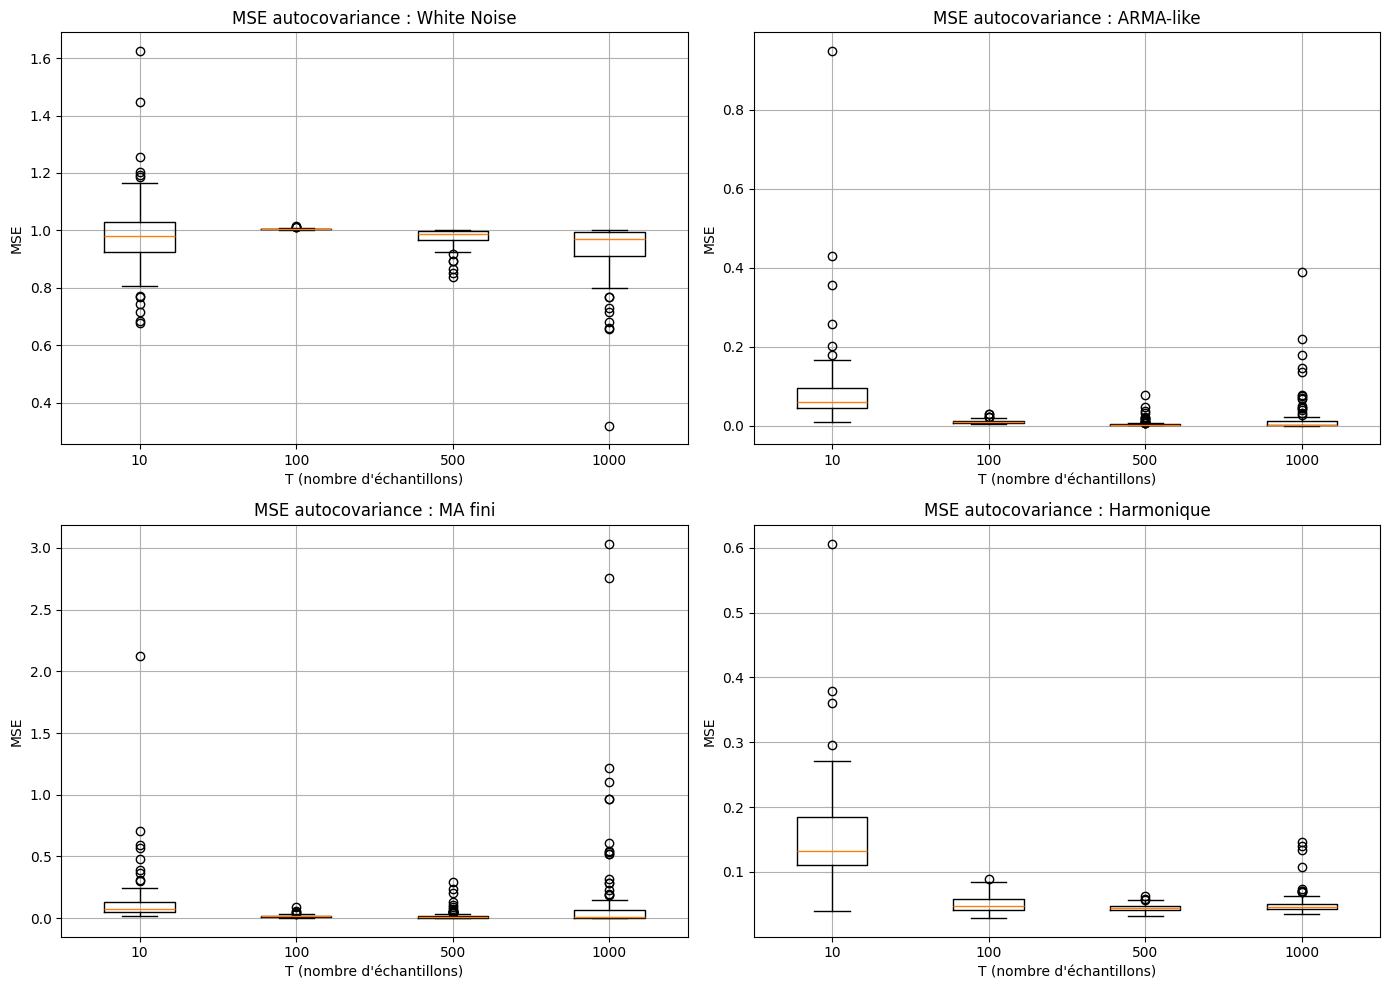

In [ ]:
# ---------------------------
# Q4. MSE et Boxplot
# ---------------------------
sigma = 1.0
a = 0.0
b = 0.5
K = 50
A0 = 1.0
lambda0 = np.pi / 10
T_list = [10, 100, 500, 1000]
n_simulations = 100


def mse_gamma(gamma_theo, gamma_emp):
    """
    Mean Squared Error between theoretical and empirical autocovariances
    Return: float (scalar MSE)
    """
    mse = 0
    size = len(gamma_theo)
    for h in range(size):
      mse += (1/size)*(gamma_theo[h]-gamma_emp[h])**2
    return mse


# implement simulation functions

def calculate_mse(X, typeX):
  size = len(X)
  gamma_emp = empirical_autocov(X)
  gamma_theo = np.zeros(size)
  if typeX == "WN":
    for h in range(size):
      gamma_theo[h] = (sigma**2)
  elif typeX == "ARMA":
    gamma_theo[0]=1+b**2
    gamma_theo[1]=b
  elif typeX == "MA":
    for h in range(K+1):
      if h<size:
        gamma_theo[h]=(1/3)*(sigma**2) * 4**(-3*h/2 +1) * (1-4**(-K+1))
  else:
    gamma_theo[0] = (1/2)+sigma**2
    for h in range(1,size):
      gamma_theo[h] = (1/2)*np.cos(lambda0*h)
  return mse_gamma(gamma_emp, gamma_theo)



def simulate_WN(T):
  return [calculate_mse(np.random.normal(0, sigma**2,T), "WN") for x in range(100)]

def simulate_ARMA(T):
  tab = [0 for i in range(100)]
  for x in range(100):
    Z= np.random.normal(0, sigma**2,T)
    X = np.array([a+b*Z[t]+Z[t-1] for t in range(T)])
    tab[x]=calculate_mse(X, "ARMA")
  return tab

def simulate_MA(T):
  tab = [0 for i in range(100)]
  for x in range(100):
    Z = np.random.normal(0, sigma, T + K)
    coeffs = np.array([2 ** (-k) for k in range(K + 1)])
    X_MA=[sum([coeffs[k]*Z[t-k] for k in range(K+1)])+a for t in range(T)]
    tab[x]=calculate_mse(X_MA, "MA")
  return tab

def simulate_Harm(T):
  tab = [0 for i in range(100)]
  for x in range(100):
    Phi0 = np.random.uniform(0, 2 * np.pi)
    Z = np.random.normal(0, sigma, T)
    t = np.arange(T)
    X_Harm = A0 * np.cos(lambda0 * t + Phi0) + Z
    tab[x]=calculate_mse(X_Harm, "Harm")
  return tab

MSE_WN = {T: simulate_WN(T) for T in T_list}
MSE_ARMA = {T: simulate_ARMA(T) for T in T_list}
MSE_MA = {T: simulate_MA(T) for T in T_list}
MSE_Harm = {T: simulate_Harm(T) for T in T_list}

MSE_results = {"White Noise": MSE_WN, "ARMA-like": MSE_ARMA, 'MA fini': MSE_MA, 'Harmonique': MSE_Harm}

# ---------------------------
# Build your loops as you like.
# Goal: produce a dict named MSE_results with shape:
# MSE_results = {
#     'White Noise':   {T: [mse_1, mse_2, ..., mse_n] for T in T_list},
#     'ARMA-like': {T: [ ... ]                     for T in T_list},
#     'MA fini':   {T: [ ... ]                     for T in T_list},
#     'Harmonique': {T: [ ... ]                     for T in T_list},
# }
# ---------------------------


# ---------------------------
# Boxplots des MSE (uncomment to visualize once MSE_results exists)
# ---------------------------
plt.figure(figsize=(14, 10))
for i, proc_name in enumerate(processes):
  plt.subplot(2, 2, i+1)
  data = [MSE_results[proc_name][T] for T in T_list]
  plt.boxplot(data, labels=T_list)
  plt.title(f"MSE autocovariance : {proc_name}")
  plt.xlabel("T (nombre d'échantillons)")
  plt.ylabel("MSE")
  plt.grid(True)

plt.tight_layout()
plt.show()

4. **[ANSWER]** We notice that, like the previous question, the White Noise has the worst MSE (the "base" of the figures near 1.0). While the best are the ARM-like and the MA fini (the "base" of the figures near 0.0, Ma fini being a little bit better because the rectangles are smaller and near 0.0). Harmonique has also good results. (the "base" of the figures between 0 and 0.1)